## Decision Tree Lab Activity: Iris Dataset

### Task 1: Dataset Exploration

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print("Iris Dataset loaded successfully.\n")

Iris Dataset loaded successfully.



### Task 6: Effect of Maximum Tree Depth

In [14]:
max_depth_values = [1, 2, 3, 4, None]
results_max_depth = []

for depth in max_depth_values:
    # Train the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    # Predict on training and testing data
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Get actual tree depth
    actual_tree_depth = dt.tree_.max_depth

    # Observation for the table
    observation = ""
    if actual_tree_depth == 0: # A depth of 0 means a single root node (no splits)
        observation = "Very simple model, likely underfitting."
    elif actual_tree_depth < 3 and depth is not None and depth > actual_tree_depth: # If max_depth was set higher than actual, means it couldn't split further
         observation = f"Tree reached its natural depth, limited by data or min_samples_split/leaf."
    elif depth is not None and actual_tree_depth == depth: # If depth was set and reached
        observation = f"Model depth limited by max_depth={depth}."
    elif depth is None: # If no max_depth was set
        observation = "Full-depth tree, potentially overfitting."
    else:
        observation = ""

    results_max_depth.append({
        'Max Depth': depth,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Tree Depth': actual_tree_depth,
        'Observation': observation
    })

# Complete the table
df_max_depth_results = pd.DataFrame(results_max_depth)
print("Effect of Maximum Tree Depth on Decision Tree Models:\n")
display(df_max_depth_results)

Effect of Maximum Tree Depth on Decision Tree Models:



,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.675000,0.633333,1,Model depth limited by max_depth=1.
1,2.0,0.950000,0.966667,2,Model depth limited by max_depth=2.
2,3.0,0.958333,1.000000,3,Model depth limited by max_depth=3.
3,4.0,0.975000,1.000000,4,Model depth limited by max_depth=4.
4,NaN,1.000000,1.000000,6,"Full-depth tree, potentially overfitting."


#### Answer the following:

*   **Which model is underfitting?**
    *   Identify the model(s) with low training accuracy and low testing accuracy. These models are too simple to capture the underlying patterns in the data.
*   **Which model gives the best generalization?**
    *   Look for the model that has a high testing accuracy and a training accuracy that is not significantly higher than the testing accuracy. This indicates a good balance between bias and variance.
*   **Which model is likely to overfit? Justify your answer.**
    *   Overfitting occurs when a model performs very well on the training data but poorly on unseen test data. Look for models with high training accuracy but noticeably lower testing accuracy. A very deep tree (often when `max_depth` is `None` or a very large number) is typically a sign of overfitting, as it learns the noise in the training data.

### Task 7: Effect of `min_samples_split`

In [15]:
min_samples_split_values = [2, 5, 10, 20]
results_min_samples_split = []

for mss_value in min_samples_split_values:
    # Train the model
    dt = DecisionTreeClassifier(min_samples_split=mss_value, random_state=42)
    dt.fit(X_train, y_train)

    # Predict on testing data
    y_test_pred = dt.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_pred)

    # Get tree depth and number of leaf nodes
    tree_depth = dt.tree_.max_depth
    num_leaf_nodes = dt.tree_.n_leaves

    # Observation
    observation = ""
    if mss_value == 2:
        observation = "Default setting, typically leads to more complex trees."
    elif mss_value < 10:
        observation = "Moderate restriction, balancing complexity and generalization."
    else:
        observation = "Stronger restriction, leading to simpler trees."

    results_min_samples_split.append({
        'min_samples_split': mss_value,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

# Complete the table
df_min_samples_split_results = pd.DataFrame(results_min_samples_split)
print("Effect of min_samples_split on Decision Tree Models:\n")
display(df_min_samples_split_results)

Effect of min_samples_split on Decision Tree Models:



,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,"Default setting, typically leads to more compl..."
1,5,1.0,5,8,"Moderate restriction, balancing complexity and..."
2,10,1.0,4,6,"Stronger restriction, leading to simpler trees."
3,20,1.0,4,6,"Stronger restriction, leading to simpler trees."


#### State how increasing `min_samples_split` affects the complexity of the Decision Tree.

*   Increasing the `min_samples_split` value means that a node in the decision tree will only split if it contains at least that many samples. This acts as a regularization parameter:
    *   **Higher `min_samples_split`:** Leads to **simpler trees**. The tree will have fewer splits, resulting in a shallower tree with fewer leaf nodes. This reduces the model's complexity, making it less prone to overfitting but potentially increasing underfitting.
    *   **Lower `min_samples_split`:** Allows the tree to make more splits, even with a small number of samples, leading to **more complex trees**. This can capture more nuances in the training data but increases the risk of overfitting.

### Task 8: Effect of `min_samples_leaf`

In [16]:
min_samples_leaf_values = [1, 2, 5, 10]
results_min_samples_leaf = []

for msl_value in min_samples_leaf_values:
    # Train the model
    dt = DecisionTreeClassifier(min_samples_leaf=msl_value, random_state=42)
    dt.fit(X_train, y_train)

    # Predict on testing data
    y_test_pred = dt.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_pred)

    # Get tree depth and number of leaf nodes
    tree_depth = dt.tree_.max_depth
    num_leaf_nodes = dt.tree_.n_leaves

    # Observation
    observation = ""
    if msl_value == 1:
        observation = "Default setting, allows for highly specific leaves, prone to overfitting."
    elif msl_value < 5:
        observation = "Moderate restriction, balancing detail and generalization."
    else:
        observation = "Stronger restriction, forcing simpler, more general leaves."

    results_min_samples_leaf.append({
        'min_samples_leaf': msl_value,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': observation
    })

# Complete the table
df_min_samples_leaf_results = pd.DataFrame(results_min_samples_leaf)
print("Effect of min_samples_leaf on Decision Tree Models:\n")
display(df_min_samples_leaf_results)

Effect of min_samples_leaf on Decision Tree Models:



,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,"Default setting, allows for highly specific le..."
1,2,1.000000,5,8,"Moderate restriction, balancing detail and gen..."
2,5,1.000000,4,6,"Stronger restriction, forcing simpler, more ge..."
3,10,0.966667,4,6,"Stronger restriction, forcing simpler, more ge..."


#### Explain how changing `min_samples_leaf` influences overfitting.

*   The `min_samples_leaf` parameter specifies the minimum number of samples required to be at a leaf node. This is a critical hyperparameter for controlling overfitting:
    *   **Lower `min_samples_leaf` (e.g., 1):** Allows the tree to create leaf nodes with very few samples. This means the tree can learn very specific patterns, even noise, in the training data, leading to a more complex tree that can perfectly fit the training data. This makes the model **highly prone to overfitting**, as it might not generalize well to unseen data.
    *   **Higher `min_samples_leaf`:** Forces the tree to create leaf nodes that contain a larger minimum number of samples. This prevents the tree from making splits that result in very small, specialized leaf nodes. Consequently, the tree becomes **simpler and more generalized**, which helps to **reduce overfitting** but can potentially lead to underfitting if the value is too high and the model can't capture important patterns.

### Task 9: Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

GridSearchCV completed.


In [18]:
# Report Best hyperparameter combination.
best_params = grid_search.best_params_
print(f"Best Hyperparameter Combination: {best_params}\n")

# Report Best cross validation score.
best_score = grid_search.best_score_
print(f"Best Cross-Validation Score (Accuracy): {best_score:.4f}\n")

# Test accuracy of the optimized model.
optimized_dt = grid_search.best_estimator_
y_pred_optimized = optimized_dt.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Test Accuracy of Optimized Model: {test_accuracy_optimized:.4f}\n")

# Compare the optimized model with the default Decision Tree model.
# The default model's accuracy was calculated in Task 3.
print(f"Default Decision Tree Model Test Accuracy: {accuracy:.4f}") # 'accuracy' from Task 3

print("\nComparison:\n")
if test_accuracy_optimized > accuracy:
    print(f"The optimized model shows improved performance with an accuracy of {test_accuracy_optimized:.4f} compared to the default model's {accuracy:.4f}.")
elif test_accuracy_optimized < accuracy:
    print(f"The optimized model shows slightly reduced performance with an accuracy of {test_accuracy_optimized:.4f} compared to the default model's {accuracy:.4f}.")
else:
    print(f"The optimized model achieves the same performance as the default model with an accuracy of {test_accuracy_optimized:.4f}.")

# Optional: Display classification report for optimized model
print("\nClassification Report for Optimized Model:")
print(classification_report(y_test, y_pred_optimized, target_names=target_names))

Best Hyperparameter Combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation Score (Accuracy): 0.9583

Test Accuracy of Optimized Model: 1.0000

Default Decision Tree Model Test Accuracy: 0.9667

Comparison:

The optimized model shows improved performance with an accuracy of 1.0000 compared to the default model's 0.9667.

Classification Report for Optimized Model:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Task 10: Analysis

#### Answer the following questions.

*   **What is the role of the criterion parameter in a Decision Tree?**
    *   The `criterion` parameter (e.g., 'gini' or 'entropy') determines the quality of a split. It measures the impurity of the nodes. The algorithm chooses the split that results in the greatest reduction in impurity. Gini impurity measures the probability of misclassifying a randomly chosen element, while entropy measures the disorder or uncertainty in a node. Both aim to create homogeneous child nodes.

*   **How does `max_depth` influence underfitting and overfitting?**
    *   **Low `max_depth`:** Can lead to **underfitting**. The tree is too shallow and simple to capture the complexity of the data, resulting in poor performance on both training and test sets.
    *   **High (or `None`) `max_depth`:** Can lead to **overfitting**. The tree becomes too complex, learns the noise in the training data, and may perfectly fit the training set but performs poorly on unseen test data.
    *   **Optimal `max_depth`:** Strikes a balance, allowing the tree to learn meaningful patterns without memorizing the noise, leading to good generalization.

*   **Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**
    *   **`min_samples_split`:** A larger value means a node must have more samples to be considered for splitting. This directly reduces the number of possible splits and thus prevents the tree from growing too deep or complex, leading to simpler trees.
    *   **`min_samples_leaf`:** A larger value means a leaf node must contain at least that many samples. This prevents the creation of leaves with very few samples, forcing earlier splits to produce larger, more general leaf nodes. This also prunes the tree, making it simpler and more robust to noise.

*   **Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.**
    *   *(Refer to your results from Task 6 to identify which `max_depth` values led to significant changes in accuracy. For example, a `max_depth` of 1 often shows very low accuracy, indicating a strong impact.)*

*   **Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**
    *   *(Consider the results from Task 9 (GridSearchCV) to identify the best hyperparameter combination. Justify your choice by referring to the test accuracy, and how these parameters balance bias and variance, preventing both underfitting and overfitting based on the earlier tasks.)*

In [2]:
# How many samples and features are present in the dataset?
num_samples = X.shape[0]
num_features = X.shape[1]
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}\n")

Number of samples: 150
Number of features: 4



In [3]:
# List the feature names and target classes.
feature_names = iris.feature_names
target_names = iris.target_names
print(f"Feature names: {feature_names}")
print(f"Target class names: {target_names}\n")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target class names: ['setosa' 'versicolor' 'virginica']



In [6]:
# Display the first five records.
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = [target_names[i] for i in y]
print("First five records of the dataset:")
display(df_iris.head())
print("\n")

First five records of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Display the class distribution.
print("Class distribution:")
display(df_iris['species'].value_counts())
print("\n")

Class distribution:


KeyError: 'species'

### Task 2: Data Preparation

In [7]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets using random_state=42.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)



#### Explanation for splitting the dataset:

The dataset is divided into training and testing sets for several key reasons:

1.  **Model Evaluation (Generalization):** The primary reason is to evaluate how well a machine learning model generalizes to unseen data. A model that performs well only on the data it was trained on (training set) but poorly on new data (test set) is said to be overfitting. Splitting the data helps detect overfitting.
2.  **Unbiased Performance Estimation:** The training set is used to train the model, allowing it to learn patterns and relationships. The test set, which the model has never seen, is then used to provide an unbiased estimate of the model's performance in a real-world scenario.
3.  **Preventing Data Leakage:** If the same data were used for both training and testing, the model might memorize the training examples rather than learn general rules. This would lead to an overly optimistic evaluation of its performance.
4.  **Hyperparameter Tuning:** In more complex scenarios, a third set (validation set) is often used for hyperparameter tuning to further prevent data leakage from the test set.

### Task 3: Building a Decision Tree Classifier

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters.
dt_classifier = DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully with default parameters.\n")

Decision Tree Classifier trained successfully with default parameters.



In [9]:
# Predict the class labels for the test dataset.
y_pred = dt_classifier.predict(X_test)

print("Predictions made on the test set.\n")

Predictions made on the test set.



In [10]:
# Evaluate the model using:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
display(pd.DataFrame(conf_matrix, index=target_names, columns=target_names))
print("\n")

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=target_names)
print("Classification Report:")
print(class_report)

Accuracy Score: 1.0000

Confusion Matrix:


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,0
virginica,0,0,11




Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Task 4: Visualizing the Decision Tree

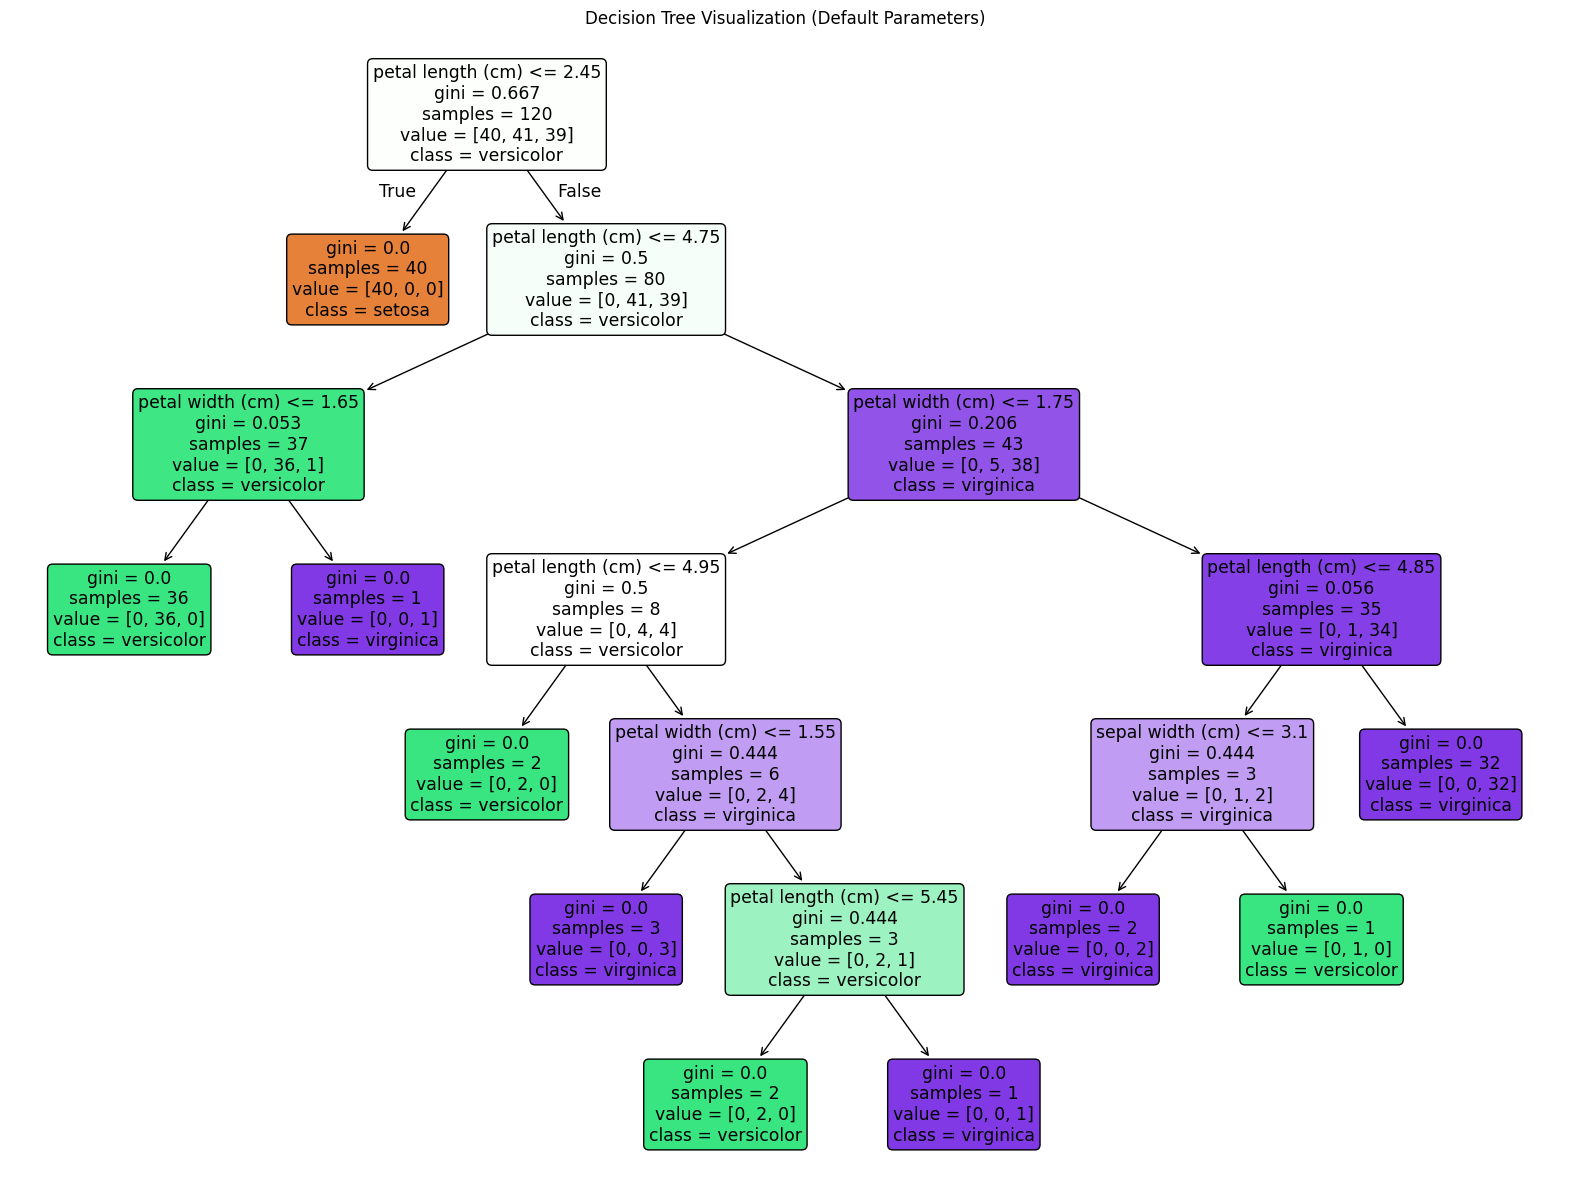

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the trained Decision Tree using plot_tree().
plt.figure(figsize=(20, 15))
plot_tree(dt_classifier,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization (Default Parameters)")
plt.show()

#### From the visualization, identify:

*   **Root node:** This is the very first node at the top of the tree, representing the initial split of the entire dataset. It is usually identified by `X[i] <= threshold` where `i` refers to the feature index.
*   **Internal nodes:** These are the nodes that have branches leading to further splits. They represent conditions on features that further divide the data. Each internal node contains a condition (`feature <= value`), a `gini` or `entropy` value, the number of `samples` that reach this node, and the `value` (distribution of classes) at this node.
*   **Leaf nodes:** These are the terminal nodes of the tree, meaning they do not split further. Each leaf node represents a final classification decision. They are typically identified by having `value = [count_class_0, count_class_1, ...]` and a `class` label, and they do not have arrows pointing down from them.
*   **Maximum depth of the tree:** This is the length of the longest path from the root node to a leaf node. You can count the levels or observe the deepest leaf node.
*   **Which feature is selected for the first split? Explain why you think this feature was chosen.**
    *   The feature selected for the first split (root node) is the one that results in the **greatest reduction in impurity** (Gini impurity in this case) among all possible features and split points. Decision Trees are greedy algorithms that aim to make the best possible split at each step. This initial split aims to separate the classes as effectively as possible right from the start. To identify it, look at the very top node of the tree and see which feature is used in the `feature <= value` condition.

### Task 5: Comparing Gini Index and Entropy

In [12]:
from sklearn.tree import DecisionTreeClassifier, export_text
import numpy as np

# Train two Decision Tree models
# Model 1: criterion='gini'
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
tree_depth_gini = dtc_gini.tree_.max_depth
leaf_nodes_gini = dtc_gini.tree_.n_leaves
root_feature_gini_idx = dtc_gini.tree_.feature[0] # The feature index for the root node
root_feature_gini = feature_names[root_feature_gini_idx]

print("Model with Gini criterion trained and evaluated.")

# Model 2: criterion='entropy'
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
tree_depth_entropy = dtc_entropy.tree_.max_depth
leaf_nodes_entropy = dtc_entropy.tree_.n_leaves
root_feature_entropy_idx = dtc_entropy.tree_.feature[0] # The feature index for the root node
root_feature_entropy = feature_names[root_feature_entropy_idx]

print("Model with Entropy criterion trained and evaluated.\n")

Model with Gini criterion trained and evaluated.
Model with Entropy criterion trained and evaluated.



In [13]:
# Summarize observations in a table.
summary_data = {
    'Criterion': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_gini, accuracy_entropy],
    'Tree Depth': [tree_depth_gini, tree_depth_entropy],
    'Number of Leaf Nodes': [leaf_nodes_gini, leaf_nodes_entropy],
    'Root Feature Selected': [root_feature_gini, root_feature_entropy]
}

df_summary = pd.DataFrame(summary_data)
print("Comparison of Decision Tree models based on Gini and Entropy criteria:")
display(df_summary)

# Which criterion produces a simpler tree?
# A simpler tree typically has lower depth and fewer leaf nodes.
# We can compare these values from the table.

print("\nWhich criterion produces a simpler tree?")
if tree_depth_gini < tree_depth_entropy and leaf_nodes_gini < leaf_nodes_entropy:
    print("Based on tree depth and number of leaf nodes, Gini criterion produces a simpler tree.")
elif tree_depth_entropy < tree_depth_gini and leaf_nodes_entropy < leaf_nodes_gini:
    print("Based on tree depth and number of leaf nodes, Entropy criterion produces a simpler tree.")
elif tree_depth_gini == tree_depth_entropy and leaf_nodes_gini == leaf_nodes_entropy:
    print("Both Gini and Entropy criteria produced trees of similar complexity (depth and number of leaf nodes).")
else:
    print("The simplicity depends on a combination of tree depth and number of leaf nodes. Refer to the table above for details.")

Comparison of Decision Tree models based on Gini and Entropy criteria:


,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature Selected
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)



Which criterion produces a simpler tree?
Both Gini and Entropy criteria produced trees of similar complexity (depth and number of leaf nodes).
